<a href="https://colab.research.google.com/github/Aaditya1412/breast_cancer_detection/blob/main/Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Google Drive mounted successfully!
Loading dataset...
Data loaded from UCI repository!

Data Preprocessing...
Dataset Shape: (569, 32)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390     

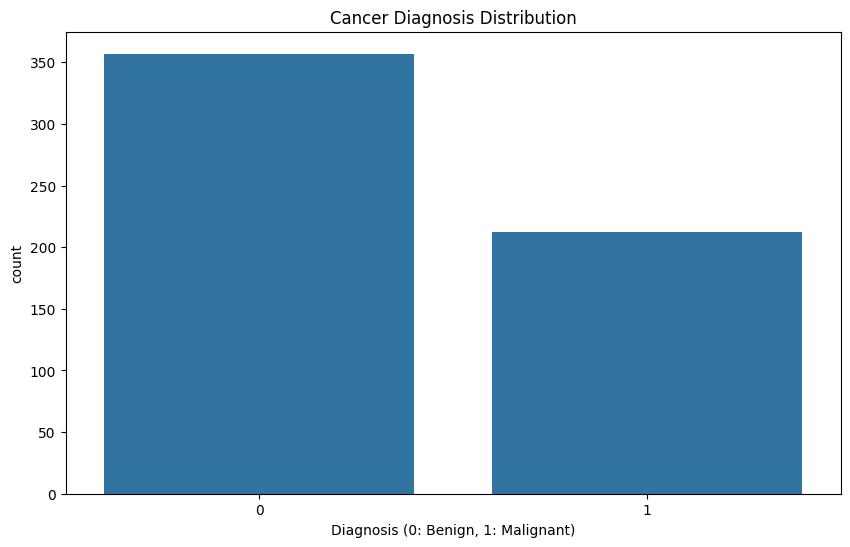

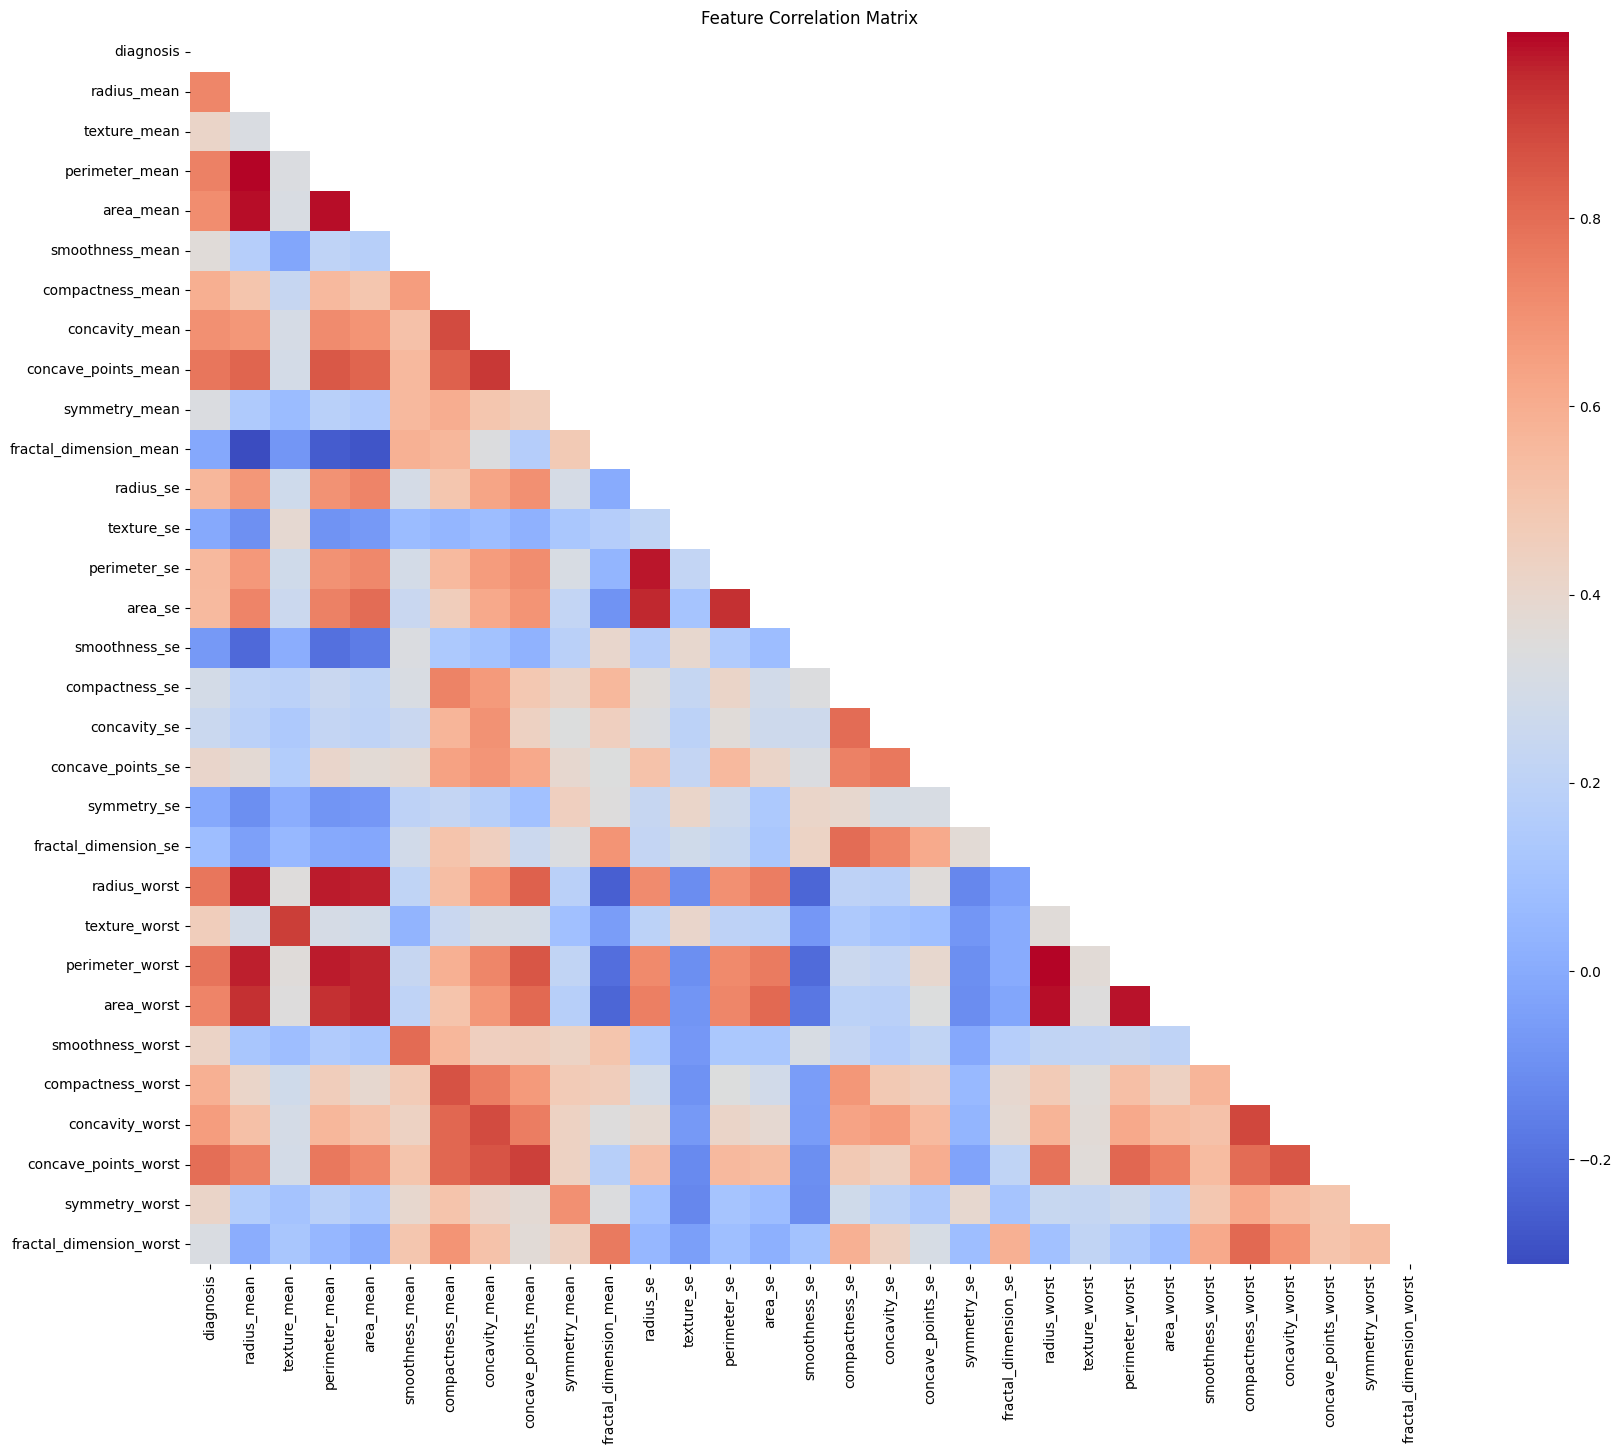


Top 10 Features Correlated with Diagnosis:
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


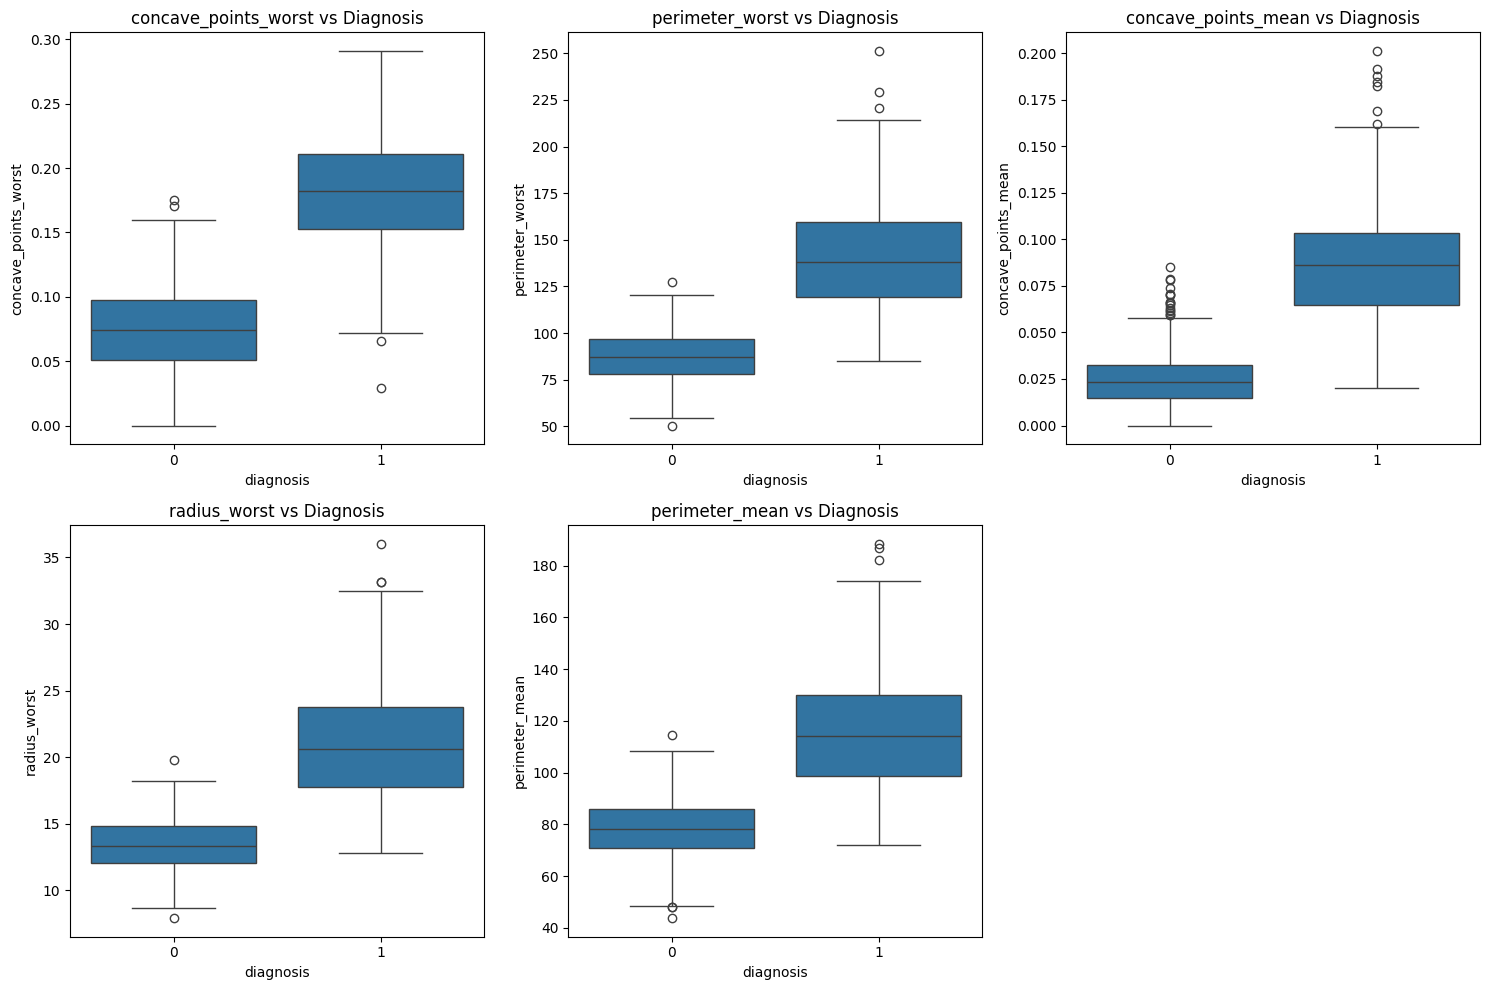

<Figure size 1500x1000 with 0 Axes>

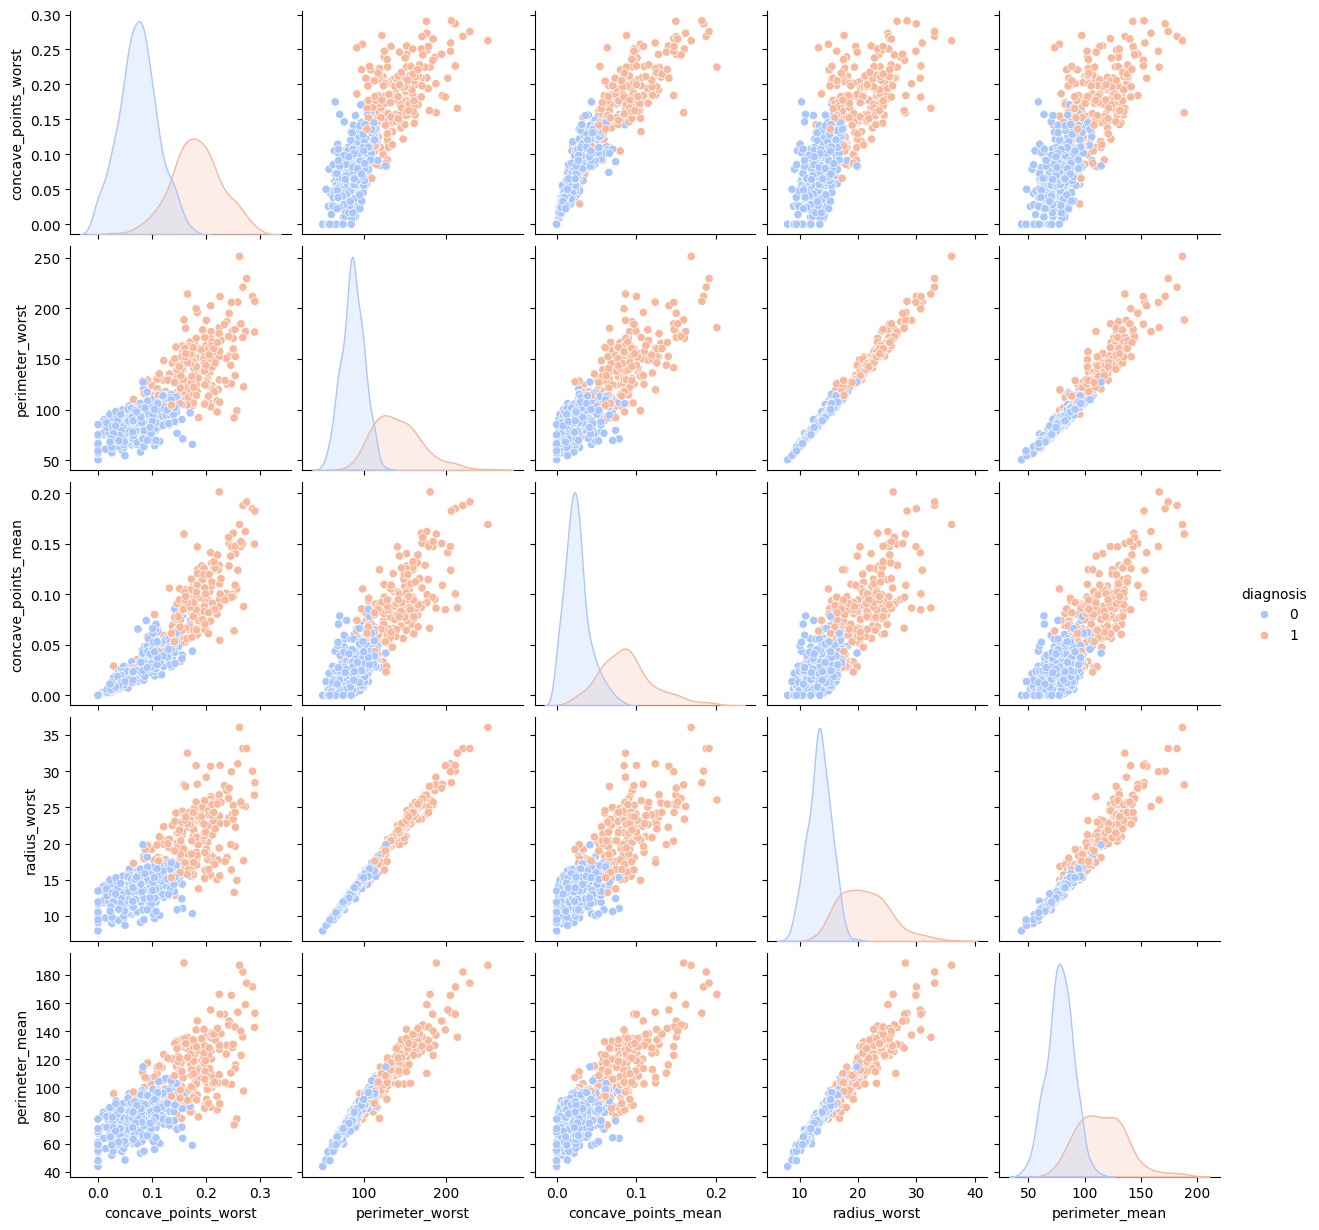


Feature Scaling...

Splitting data into training and testing sets...
Training set shape: (455, 30)
Testing set shape: (114, 30)

Model Training and Evaluation...

Training Logistic Regression...

Logistic Regression Results:
Test Accuracy: 0.9649
Cross-Validation Accuracy: 0.9807 ± 0.0065


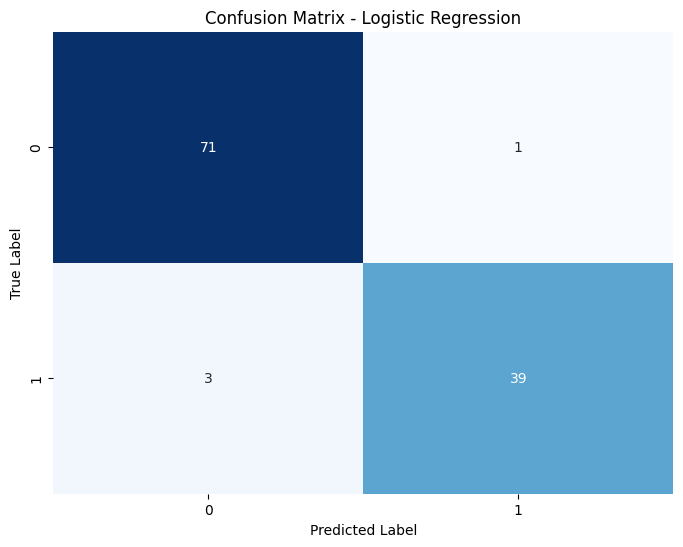


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



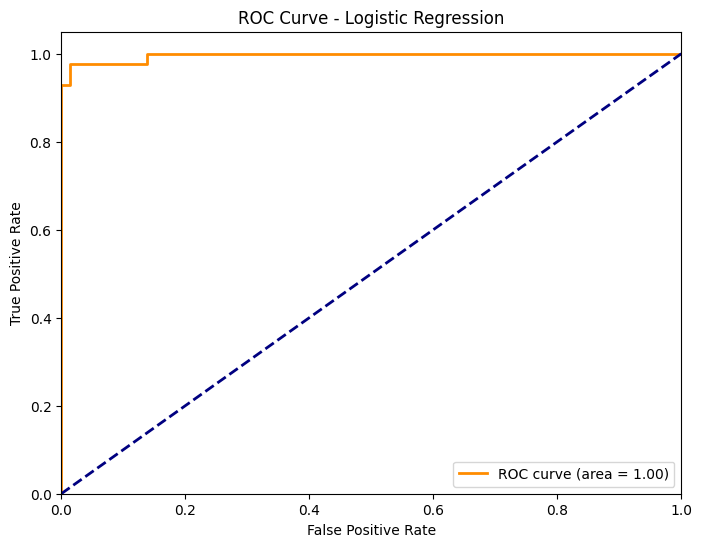


Training KNN...

K-Nearest Neighbors Results:
Test Accuracy: 0.9561
Cross-Validation Accuracy: 0.9649 ± 0.0096


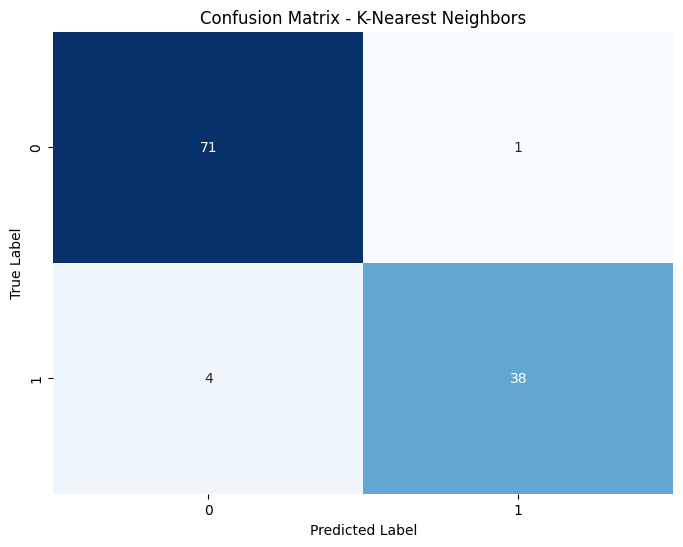


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



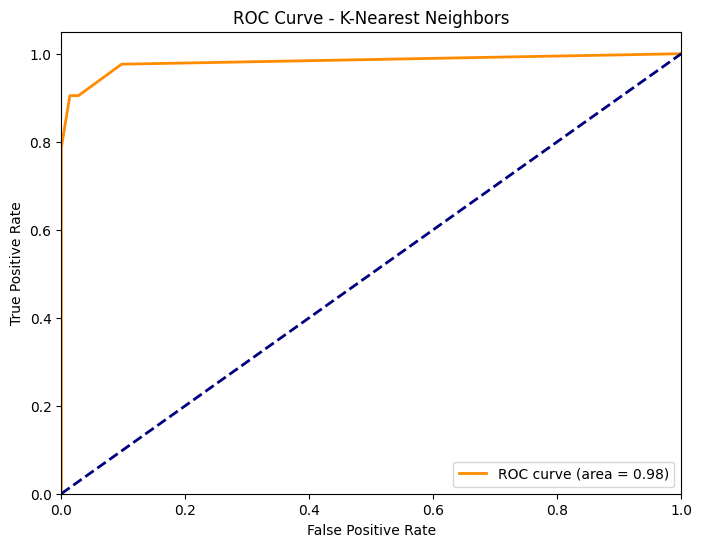


Training SVM...

Support Vector Machine Results:
Test Accuracy: 0.9737
Cross-Validation Accuracy: 0.9736 ± 0.0147


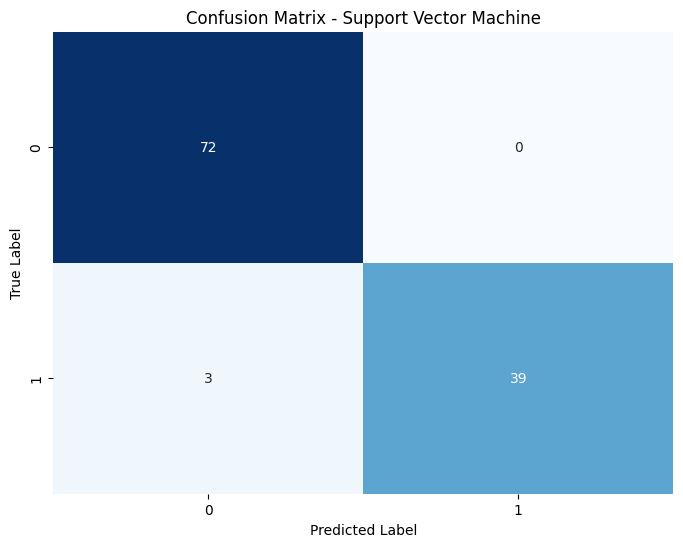


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



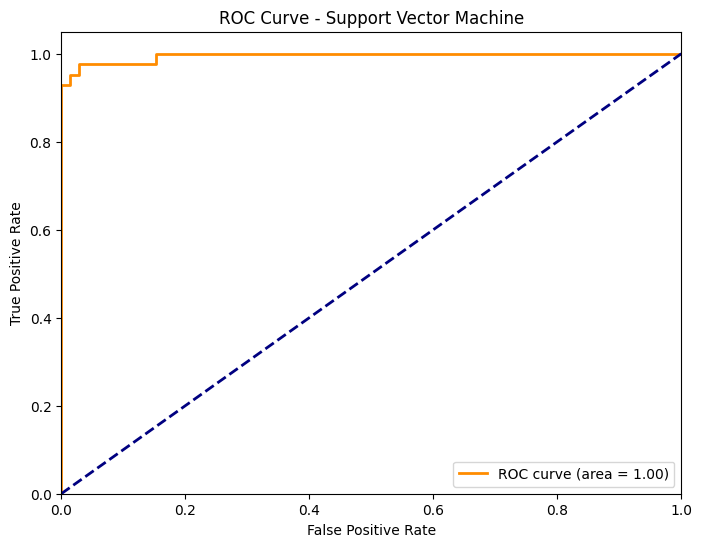


Training Random Forest...

Random Forest Results:
Test Accuracy: 0.9737
Cross-Validation Accuracy: 0.9543 ± 0.0217


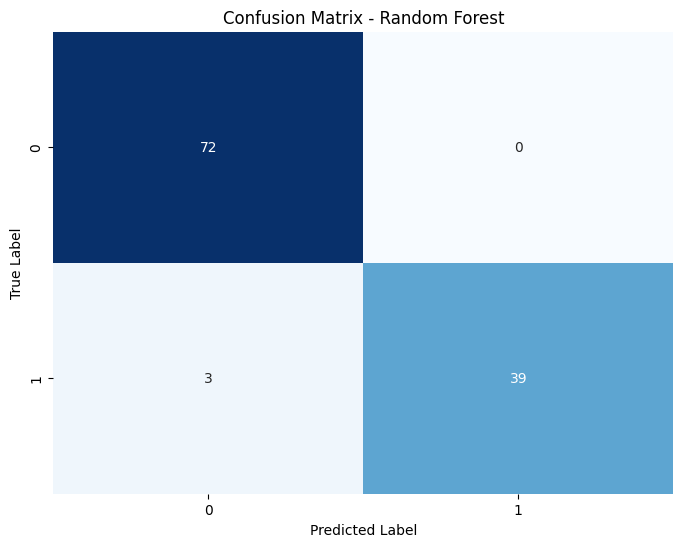


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



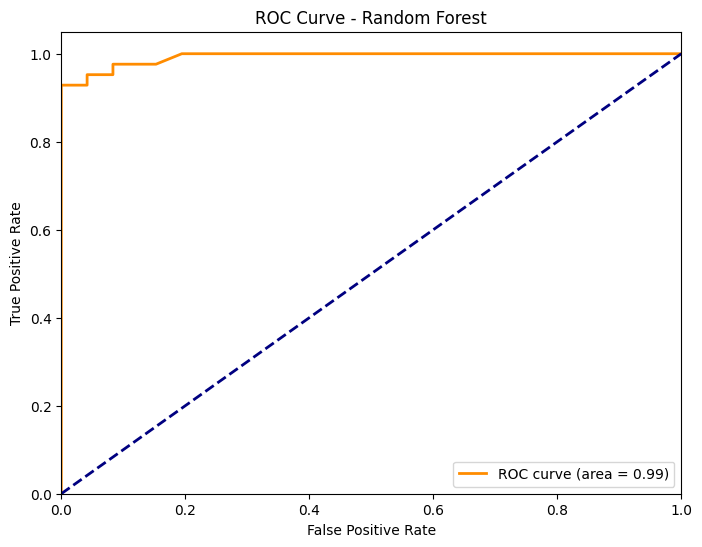


The best performing model is: Logistic Regression with CV accuracy: 0.9807

Performing Hyperparameter Tuning for Logistic Regression...

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Tuned Logistic Regression Results:
Test Accuracy: 0.9825
Cross-Validation Accuracy: 0.9824 ± 0.0055


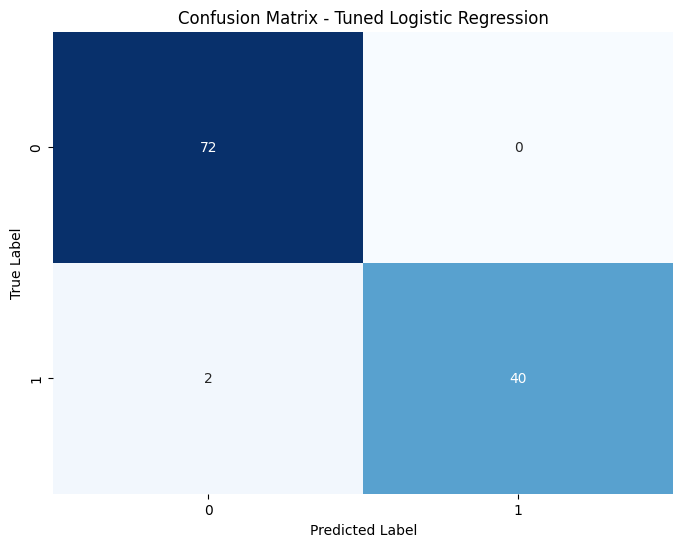


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



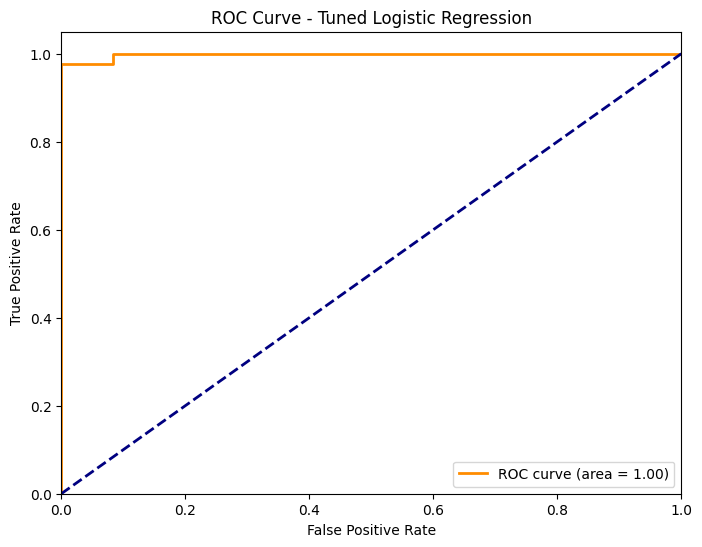


Improvement after Tuning:
Original Logistic Regression Test Accuracy: 0.9649
Tuned Logistic Regression Test Accuracy: 0.9825
Improvement: 1.75%

Generating Learning Curve for the Tuned Model...


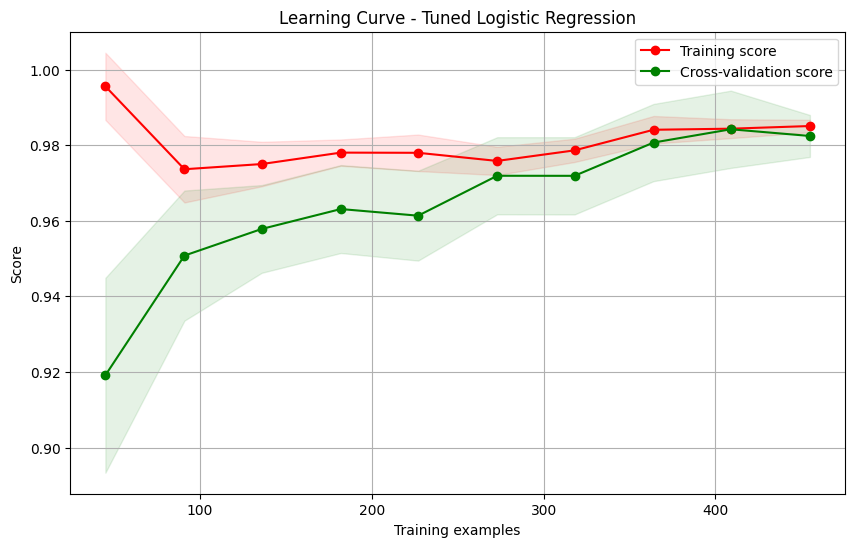


11. Example of using the prediction function
Prediction for sample patient: Malignant
Probability of being Malignant: 1.0000
True label: Benign

Model and scaler saved successfully!
Model and scaler also saved to Google Drive!

Model Training and Evaluation Completed!

Summary of Model Performance:
--------------------------------------------------
Model                     Test Acc     CV Acc      
--------------------------------------------------
Logistic Regression       0.9649       0.9807      
K-Nearest Neighbors       0.9561       0.9649      
Support Vector Machine    0.9737       0.9736      
Random Forest             0.9737       0.9543      
--------------------------------------------------
Tuned Logistic Regression 0.9825       N/A         
--------------------------------------------------

Recommendation:
The Logistic Regression model with tuned hyperparameters performed best with an accuracy of 0.9825.
This model is recommended for breast cancer prediction based on th

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except:
    print("Google Drive not mounted. Running locally.")
# Option 1: Load from URL
try:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
    column_names = ["id", "diagnosis", "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
                    "smoothness_mean", "compactness_mean", "concavity_mean", "concave_points_mean",
                    "symmetry_mean", "fractal_dimension_mean", "radius_se", "texture_se", "perimeter_se",
                    "area_se", "smoothness_se", "compactness_se", "concavity_se", "concave_points_se",
                    "symmetry_se", "fractal_dimension_se", "radius_worst", "texture_worst", "perimeter_worst",
                    "area_worst", "smoothness_worst", "compactness_worst", "concavity_worst",
                    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"]

    data = pd.read_csv(url, names=column_names)
except:
    # Option 2: Load from Kaggle (requires authentication)
    print("Couldn't load from UCI. Trying alternative sources...")
    try:
        # Option 3: Load from GitHub
        url = "https://raw.githubusercontent.com/MohitKumarMandhre/Breast-Cancer-Detection-Kaggle/master/data.csv"
        data = pd.read_csv(url)
        print("Data loaded from GitHub repository!")
    except:
        print("Please upload the breast cancer dataset manually")
        from google.colab import files
        uploaded = files.upload()
        data = pd.read_csv(next(iter(uploaded)))

# 2. Data Preprocessing
print("\nData Preprocessing...")
# Check dataset structure
print(f"Dataset Shape: {data.shape}")
print("\nFirst 5 rows:")
print(data.head())

# Data Information
print("\nData Information:")
data.info()

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# For Kaggle dataset format, rename columns if necessary
if 'diagnosis' not in data.columns and 'Diagnosis' in data.columns:
    data = data.rename(columns={'Diagnosis': 'diagnosis'})

# Handle missing values if any
data = data.dropna()

# Convert diagnosis to binary: M (malignant) = 1, B (benign) = 0
if data['diagnosis'].dtype == 'object':
    data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Remove ID column if it exists
if 'id' in data.columns:
    data = data.drop('id', axis=1)
elif 'ID' in data.columns:
    data = data.drop('ID', axis=1)
elif 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)

# Separate features and target
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# 3. Data Visualization
print("\nData Visualization...")

plt.figure(figsize=(10, 6))
sns.countplot(x=y)
plt.title('Cancer Diagnosis Distribution')
plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
plt.savefig('diagnosis_distribution.png')
plt.show()

# Correlation Matrix
plt.figure(figsize=(20, 16))
correlation = data.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=False, mask=mask, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

# Top 10 features with highest correlation to diagnosis
correlation_with_target = abs(correlation['diagnosis'])
print("\nTop 10 Features Correlated with Diagnosis:")
print(correlation_with_target.sort_values(ascending=False)[1:11])

# Visualize most significant features
top_features = correlation_with_target.sort_values(ascending=False)[1:6].index

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=data)
    plt.title(f'{feature} vs Diagnosis')
plt.tight_layout()
plt.savefig('top_features_boxplots.png')
plt.show()

# Create pair plot for top features
plt.figure(figsize=(15, 10))
sns.pairplot(data=data[['diagnosis'] + list(top_features)], hue='diagnosis', palette='coolwarm')
plt.savefig('pairplot_top_features.png')
plt.show()

# Feature Scaling
print("\nFeature Scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
print("\nSplitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Model Building and Evaluation
print("\nModel Training and Evaluation...")

# Function to evaluate and visualize model performance
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_prob = None
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

    # Print results
    print(f"\n{model_name} Results:")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png')
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(class_report)

    # ROC Curve (if applicable)
    if y_pred_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc="lower right")
        plt.savefig(f'roc_curve_{model_name.replace(" ", "_").lower()}.png')
        plt.show()

    return model, accuracy, cv_scores.mean()

# Dictionary to store model results
model_results = {}

#  Logistic Regression
print("\nTraining Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model, log_reg_acc, log_reg_cv = evaluate_model(log_reg, "Logistic Regression", X_train, X_test, y_train, y_test)
model_results["Logistic Regression"] = (log_reg_acc, log_reg_cv)

#K-Nearest Neighbors
print("\nTraining KNN...")
knn = KNeighborsClassifier()
knn_model, knn_acc, knn_cv = evaluate_model(knn, "K-Nearest Neighbors", X_train, X_test, y_train, y_test)
model_results["K-Nearest Neighbors"] = (knn_acc, knn_cv)

# Support Vector Machine
print("\nTraining SVM...")
svm = SVC(probability=True, random_state=42)
svm_model, svm_acc, svm_cv = evaluate_model(svm, "Support Vector Machine", X_train, X_test, y_train, y_test)
model_results["Support Vector Machine"] = (svm_acc, svm_cv)

# Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(random_state=42)
rf_model, rf_acc, rf_cv = evaluate_model(rf, "Random Forest", X_train, X_test, y_train, y_test)
model_results["Random Forest"] = (rf_acc, rf_cv)

#  Hyperparameter Tuning for the best model
# Find the model with the highest cross-validation score
best_model_name = max(model_results, key=lambda k: model_results[k][1])
print(f"\nThe best performing model is: {best_model_name} with CV accuracy: {model_results[best_model_name][1]:.4f}")

# Define hyperparameter grid for the best model
if best_model_name == "Logistic Regression":
    print("\nPerforming Hyperparameter Tuning for Logistic Regression...")
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    best_model = LogisticRegression(random_state=42, max_iter=1000)

elif best_model_name == "K-Nearest Neighbors":
    print("\nPerforming Hyperparameter Tuning for KNN...")
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    best_model = KNeighborsClassifier()

elif best_model_name == "Support Vector Machine":
    print("\nPerforming Hyperparameter Tuning for SVM...")
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    best_model = SVC(probability=True, random_state=42)

else:  # Random Forest
    print("\nPerforming Hyperparameter Tuning for Random Forest...")
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
    }
    best_model = RandomForestClassifier(random_state=42)


grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


print("\nBest Parameters:", grid_search.best_params_)


tuned_model = grid_search.best_estimator_
tuned_model, tuned_acc, tuned_cv = evaluate_model(tuned_model, f"Tuned {best_model_name}", X_train, X_test, y_train, y_test)

print("\nImprovement after Tuning:")
print(f"Original {best_model_name} Test Accuracy: {model_results[best_model_name][0]:.4f}")
print(f"Tuned {best_model_name} Test Accuracy: {tuned_acc:.4f}")
print(f"Improvement: {(tuned_acc - model_results[best_model_name][0])*100:.2f}%")


if best_model_name == "Random Forest":

    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': tuned_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\nTop 10 Important Features:")
    print(feature_importance.head(10))


    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

#  Learning Curves
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy')

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std,
                     test_mean + test_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    plt.savefig(f'learning_curve_{title.replace(" ", "_").lower()}.png')
    plt.show()

print("\nGenerating Learning Curve for the Tuned Model...")
plot_learning_curve(tuned_model, f"Learning Curve - Tuned {best_model_name}", X_scaled, y)


def predict_cancer(model, scaler, input_data):
    """
    Function to predict cancer type for new patient data

    Parameters:
    - model: Trained ML model
    - scaler: Fitted StandardScaler
    - input_data: DataFrame or array with patient features

    Returns:
    - Prediction: 0 (Benign) or 1 (Malignant)
    - Probability of prediction
    """

    if isinstance(input_data, pd.DataFrame):
        if input_data.shape[1] != X.shape[1]:
            print(f"Error: Input data should have {X.shape[1]} features.")
            return None, None
    else:

        input_data = np.array(input_data).reshape(1, -1)
        if input_data.shape[1] != X.shape[1]:
            print(f"Error: Input data should have {X.shape[1]} features.")
            return None, None

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]


    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(input_scaled)[0][1]
    else:
        probability = None

    result = 'Malignant' if prediction == 1 else 'Benign'

    return result, probability

print("\n11. Example of using the prediction function")

sample_index = 0
sample_data = X_test[sample_index:sample_index+1]
true_label = y_test.iloc[sample_index] if isinstance(y_test, pd.Series) else y_test[sample_index]


result, probability = predict_cancer(tuned_model, scaler, sample_data)

print(f"Prediction for sample patient: {result}")
if probability is not None:
    print(f"Probability of being Malignant: {probability:.4f}")
print(f"True label: {'Malignant' if true_label == 1 else 'Benign'}")

# 12. Save the model (optional)
import pickle

# Save the model and scaler
try:
    with open('breast_cancer_model.pkl', 'wb') as file:
        pickle.dump(tuned_model, file)

    with open('breast_cancer_scaler.pkl', 'wb') as file:
        pickle.dump(scaler, file)

    print("\nModel and scaler saved successfully!")

    # Save to Google Drive if mounted
    try:
        with open('/content/drive/MyDrive/breast_cancer_model.pkl', 'wb') as file:
            pickle.dump(tuned_model, file)

        with open('/content/drive/MyDrive/breast_cancer_scaler.pkl', 'wb') as file:
            pickle.dump(scaler, file)

        print("Model and scaler also saved to Google Drive!")
    except:
        print("Could not save to Google Drive. Check if it's mounted.")

except:
    print("\nCould not save the model and scaler.")

print("\nModel Training and Evaluation Completed!")

print("\nSummary of Model Performance:")
print("-" * 50)
print("{:<25} {:<12} {:<12}".format("Model", "Test Acc", "CV Acc"))
print("-" * 50)
for model_name, (test_acc, cv_acc) in model_results.items():
    print("{:<25} {:<12.4f} {:<12.4f}".format(model_name, test_acc, cv_acc))
print("-" * 50)
print("{:<25} {:<12.4f} {:<12}".format(f"Tuned {best_model_name}", tuned_acc, "N/A"))
print("-" * 50)

print("\nRecommendation:")
print(f"The {best_model_name} model with tuned hyperparameters performed best with an accuracy of {tuned_acc:.4f}.")
print("This model is recommended for breast cancer prediction based on the given features.")


print("\nFinal Selected Model Details:")
print(tuned_model)